Stitching 37 files...
Plotting... Final Image Shape: (29600, 15624)
✅ Saved Grand Waterfall to ..\reports\figures\grand_waterfall_reconstruction.png


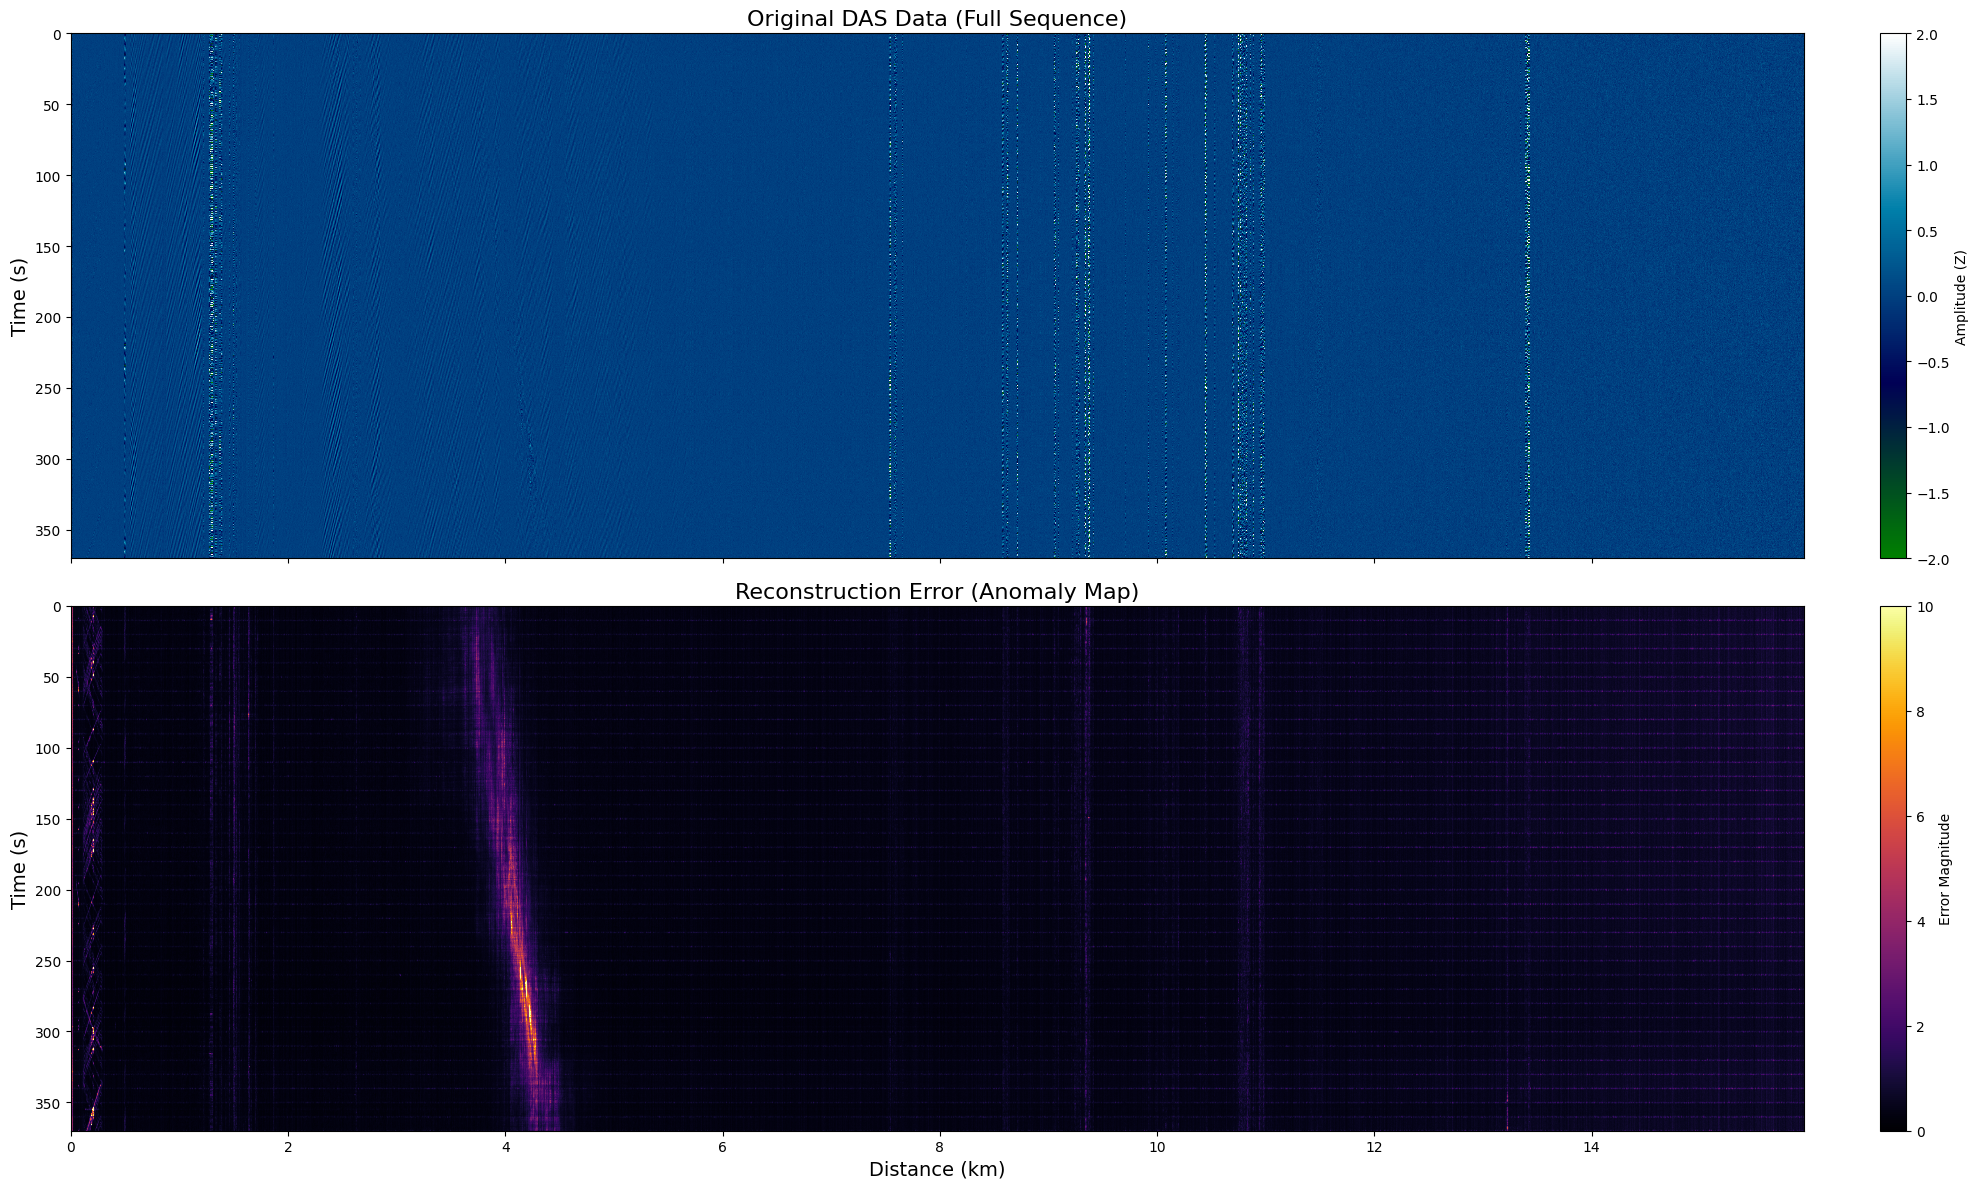

In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- CONFIGURATION ---
RAW_DIR = Path("../data/raw/inference")
RECON_DIR = Path("../data/reconstructions")
OUTPUT_DIR = Path("../reports/figures")

# VISUALIZATION SETTINGS
# 10 means we take every 10th row. 
DOWNSAMPLE_FACTOR = 10 
# Wide "Landscape" format: (Width, Height)
FIG_SIZE = (20, 12) 

def load_and_stitch(raw_path, recon_path):
    """
    Loads all files in order, downsamples them, and concatenates them.
    """
    raw_files = sorted(list(raw_path.glob("*.h5")) + list(raw_path.glob("*.hdf5")))
    recon_files = sorted(list(recon_path.glob("residual_*.h5")) + list(recon_path.glob("residual_*.hdf5")))
    
    if len(raw_files) != len(recon_files):
        print(f"Warning: Found {len(raw_files)} raw files but {len(recon_files)} reconstruction files.")
        
    full_raw = []
    full_res = []
    
    print(f"Stitching {len(recon_files)} files...")
    
    for res_file in recon_files:
        orig_name = res_file.name.replace("residual_", "")
        raw_file = next((p for p in raw_files if p.name == orig_name), None)
        
        if not raw_file:
            print(f"Skipping {res_file.name}: Original raw file not found.")
            continue
            
        try:
            with h5py.File(raw_file, 'r') as f_raw, h5py.File(res_file, 'r') as f_res:
                
                # Load RAW (Force float32, Downsample Time Axis)
                r_data = np.empty(f_raw['data'].shape, dtype=np.float32)
                f_raw['data'].read_direct(r_data)
                r_down = r_data[::DOWNSAMPLE_FACTOR, :]
                
                # Z-Score Raw Data (for consistent 'Ocean' color)
                r_down = (r_down - np.mean(r_down)) / (np.std(r_down) + 1e-6)
                full_raw.append(r_down)

                # Load RESIDUAL
                res_data = f_res['data'][:] 
                res_down = res_data[::DOWNSAMPLE_FACTOR, :]
                full_res.append(res_down)
                
                if len(full_raw) == 1:
                    dt = f_raw['header/dt'][()] * DOWNSAMPLE_FACTOR
                    dx = f_raw['header/dx'][()]

        except Exception as e:
            print(f"Error reading {res_file.name}: {e}")

    # Stack vertically (Time axis 0)
    big_raw = np.vstack(full_raw)
    big_res = np.vstack(full_res)
    
    return big_raw, big_res, dt, dx

def plot_grand_waterfall(raw, res, dt, dx):
    """
    Plots the Top-Bottom comparison with shared X-axis.
    """
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    
    print(f"Plotting... Final Image Shape: {raw.shape}")
    
    max_dist = raw.shape[1] * dx / 1000.0 # km
    max_time = raw.shape[0] * dt # seconds
    extent = [0, max_dist, max_time, 0] # [left, right, bottom, top]

    # SHAREX=True: Zooming one zooms the other
    fig, axs = plt.subplots(2, 1, figsize=FIG_SIZE, sharex=True, sharey=True)
    
    # --- PLOT 1 (TOP): THE OCEAN ---
    im0 = axs[0].imshow(raw, aspect='auto', cmap='ocean', extent=extent, vmin=-2, vmax=2)
    axs[0].set_title("Original DAS Data (Full Sequence)", fontsize=16)
    axs[0].set_ylabel("Time (s)", fontsize=14)
    # We remove the x-label here since it's shared with the bottom plot
    
    # Add colorbar to the right of the plot
    cbar0 = plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
    cbar0.set_label("Amplitude (Z)")

    # --- PLOT 2 (BOTTOM): THE ANOMALY ---
    # Using 'inferno' (Black -> Yellow)
    im1 = axs[1].imshow(res, aspect='auto', cmap='inferno', extent=extent, vmin=0, vmax=10)
    axs[1].set_title("Reconstruction Error (Anomaly Map)", fontsize=16)
    axs[1].set_ylabel("Time (s)", fontsize=14)
    axs[1].set_xlabel("Distance (km)", fontsize=14)
    
    cbar1 = plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)
    cbar1.set_label("Error Magnitude")

    plt.tight_layout()
    
    save_path = OUTPUT_DIR / "grand_waterfall_reconstruction.png"
    plt.savefig(save_path, dpi=300)
    print(f"✅ Saved Grand Waterfall to {save_path}")

if __name__ == "__main__":
    raw_arr, res_arr, dt, dx = load_and_stitch(RAW_DIR, RECON_DIR)
    
    if len(raw_arr) > 0:
        plot_grand_waterfall(raw_arr, res_arr, dt, dx)
    else:
        print("Failed to load data.")

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta, timezone
from pathlib import Path

# --- CONFIGURATION ---
RAW_DIR = Path("../data/raw/inference")
RECON_DIR = Path("../data/reconstructions")
OUTPUT_DIR = Path("../reports/figures")

# VISUALIZATION SETTINGS
DOWNSAMPLE_FACTOR = 10  # Keep every 10th time sample (prevent RAM crash)
FIG_SIZE = (20, 14)     # Big landscape plot

def get_file_metadata(path):
    """Extracts timestamp and physics parameters from HDF5."""
    with h5py.File(path, 'r') as f:
        # Get Unix timestamp (seconds since epoch)
        t0 = f['header/time'][()]
        dt = f['header/dt'][()]
        dx = f['header/dx'][()]
        shape = f['data'].shape
    return t0, dt, dx, shape

def load_and_stitch_with_time(raw_path, recon_path):
    """
    Loads all files, downsamples them, and builds a continuous Datetime axis.
    """
    # 1. Match Files
    raw_files = sorted(list(raw_path.glob("*.h5")) + list(raw_path.glob("*.hdf5")))
    recon_files = sorted(list(recon_path.glob("residual_*.h5")) + list(recon_path.glob("residual_*.hdf5")))
    
    full_raw = []
    full_res = []
    
    # We need to build the time axis relative to the very first file
    start_timestamp = None
    total_samples = 0
    current_dt = 0.0
    current_dx = 0.0

    print(f"Stitching {len(recon_files)} files...")
    
    for res_file in recon_files:
        orig_name = res_file.name.replace("residual_", "")
        # Find matching raw file
        raw_file = next((p for p in raw_files if p.name == orig_name), None)
        
        if not raw_file:
            continue
            
        try:
            # Get Metadata
            t0, dt, dx, shape = get_file_metadata(raw_file)
            
            # Capture global parameters from the first file
            if start_timestamp is None:
                start_timestamp = t0
                current_dt = dt
                current_dx = dx
            
            # Load Data (Downsampled)
            with h5py.File(raw_file, 'r') as f_raw, h5py.File(res_file, 'r') as f_res:
                
                # RAW: Read direct -> Float32 -> Downsample -> Absolute Value
                r_data = np.empty(shape, dtype=np.float32)
                f_raw['data'].read_direct(r_data)
                
                # CRITICAL CHANGE 1: Use Energy (Abs) instead of Amplitude
                r_down = np.abs(r_data[::DOWNSAMPLE_FACTOR, :])
                full_raw.append(r_down)

                # RESIDUAL: Load -> Downsample
                res_data = f_res['data'][:] 
                res_down = res_data[::DOWNSAMPLE_FACTOR, :]
                full_res.append(res_down)
                
                total_samples += r_down.shape[0]

        except Exception as e:
            print(f"Error reading {res_file.name}: {e}")

    # Stack Arrays
    if not full_raw:
        raise ValueError("No data loaded!")

    big_raw = np.vstack(full_raw)
    big_res = np.vstack(full_res)
    
    # Build Real-World Time Axis
    # Start Date
    start_datetime = datetime.fromtimestamp(start_timestamp, tz=timezone.utc)
    
    # Duration of the FULL stitched stack
    # Effective dt is larger because we downsampled
    effective_dt = current_dt * DOWNSAMPLE_FACTOR
    duration_sec = total_samples * effective_dt
    end_datetime = start_datetime + timedelta(seconds=duration_sec)
    
    return big_raw, big_res, start_datetime, end_datetime, current_dx

def plot_smart_waterfall(raw, res, t_start, t_end, dx):
    """
    Plots Raw vs Residual with Real-World Time and Smart Contrast.
    """
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    
    # Dimensions
    max_dist_km = raw.shape[1] * dx / 1000.0
    
    # Convert datetimes to Matplotlib numbers for plotting
    t_start_num = mdates.date2num(t_start)
    t_end_num = mdates.date2num(t_end)
    
    # EXTENT: [left, right, bottom, top]
    # We want Earliest Time (t_start) at the BOTTOM.
    extent = [0, max_dist_km, t_start_num, t_end_num]

    # CRITICAL CHANGE 2: Smart Contrast (Percentile)
    # This ignores the crazy loud pops and focuses on the ship/noise
    vmax_raw = np.percentile(raw, 99.5)  # Clip top 0.5% outliers
    vmax_res = np.percentile(res, 99.5)

    print(f"Plotting... Raw Vmax: {vmax_raw:.4f}, Res Vmax: {vmax_res:.4f}")

    fig, axs = plt.subplots(2, 1, figsize=FIG_SIZE, sharex=True, sharey=True)
    
    # --- PLOT 1: RAW ENERGY (JET CMAP) ---
    # origin='lower' puts the first data row at the bottom (matching t_start)
    im0 = axs[0].imshow(raw, aspect='auto', cmap='jet', origin='lower',
                        extent=extent, vmin=0, vmax=vmax_raw)
    
    axs[0].set_title(f"Raw DAS Energy (Start: {t_start.strftime('%H:%M:%S')} UTC)", fontsize=16)
    axs[0].set_ylabel("Time (UTC)", fontsize=14)
    
    # Format Y-Axis as HH:MM:SS
    axs[0].yaxis_date()
    axs[0].yaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

    cbar0 = plt.colorbar(im0, ax=axs[0], pad=0.02)
    cbar0.set_label("|Strain Rate|")

    # --- PLOT 2: ANOMALY RESIDUAL ---
    # Using 'inferno' to make the anomaly burn bright against black
    im1 = axs[1].imshow(res, aspect='auto', cmap='inferno', origin='lower',
                        extent=extent, vmin=0, vmax=vmax_res)
    
    axs[1].set_title("Anomaly Detection (Residuals)", fontsize=16)
    axs[1].set_xlabel("Distance (km)", fontsize=14)
    axs[1].set_ylabel("Time (UTC)", fontsize=14)
    
    cbar1 = plt.colorbar(im1, ax=axs[1], pad=0.02)
    cbar1.set_label("Reconstruction Error")

    plt.tight_layout()
    
    save_path = OUTPUT_DIR / "final_trajectory_analysis.png"
    plt.savefig(save_path, dpi=300)
    print(f"✅ Saved Analysis to {save_path}")

if __name__ == "__main__":
    raw_arr, res_arr, t0, t1, dx = load_and_stitch_with_time(RAW_DIR, RECON_DIR)
    if len(raw_arr) > 0:
        plot_smart_waterfall(raw_arr, res_arr, t0, t1, dx)

Stitching 0 files...


ValueError: No data loaded!